In [10]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
from sklearn.model_selection import train_test_split


print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
df = pd.read_csv(r"C:\Users\malum\Desktop\faculdade\learning_machine\dados\creditcard.csv")
print(f"Dataset carregado! Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")


Dataset carregado! Linhas: 284807 | Colunas: 31


In [4]:
total_nulos = df.isnull().sum().sum()
print(f"Total de valores nulos no dataset: {total_nulos}")

Total de valores nulos no dataset: 0


In [5]:
contagem_classes = df['Class'].value_counts().reset_index()
contagem_classes.columns = ['Classe', 'Total']
contagem_classes['Classe'] = contagem_classes['Classe'].map({0: 'Normal (Legítima)', 1: 'Fraude'})

fig_barras = px.bar(
    contagem_classes, 
    x='Classe', 
    y='Total',
    text='Total',
    title='O Desafio do Desbalanceamento Absoluto de Dados',
    labels={'Total': 'Número de Transações (Escala Log)', 'Classe': 'Tipo de Transação'},
    color='Classe',
    color_discrete_map={'Normal (Legítima)': '#2ecc71', 'Fraude': '#e74c3c'} 
)
fig_barras.update_traces(textposition='outside')
fig_barras.update_layout(height=500, template='plotly_dark', yaxis_type="log")
fig_barras.show()

In [8]:
df['Hora'] = df['Time'].apply(lambda x: np.floor(x / 3600) %24)

dataf = df.groupby(['Hora', 'Class'])['Amount'].aggregate(['sum', 'count', 'mean']).reset_index()
dataf.columns = ['Hora', 'Classe', 'Soma Total', 'Total Transacoes', 'Media Valor']

In [9]:
class_0 = df.loc[df['Class'] == 0]['Hora']
class_1 = df.loc[df['Class'] == 1]['Hora']

fig_densidade = ff.create_distplot([class_0, class_1], ['Legítima', 'Fraude'], show_hist=False, show_rug=False)
fig_densidade['layout'].update(
    title='Gráfico de Densidade: Tempo das Transações de Cartão de Crédito', 
    xaxis=dict(title='Tempo decorrido (em horas)'),
    yaxis=dict(title='Densidade')
)
fig_densidade.show()


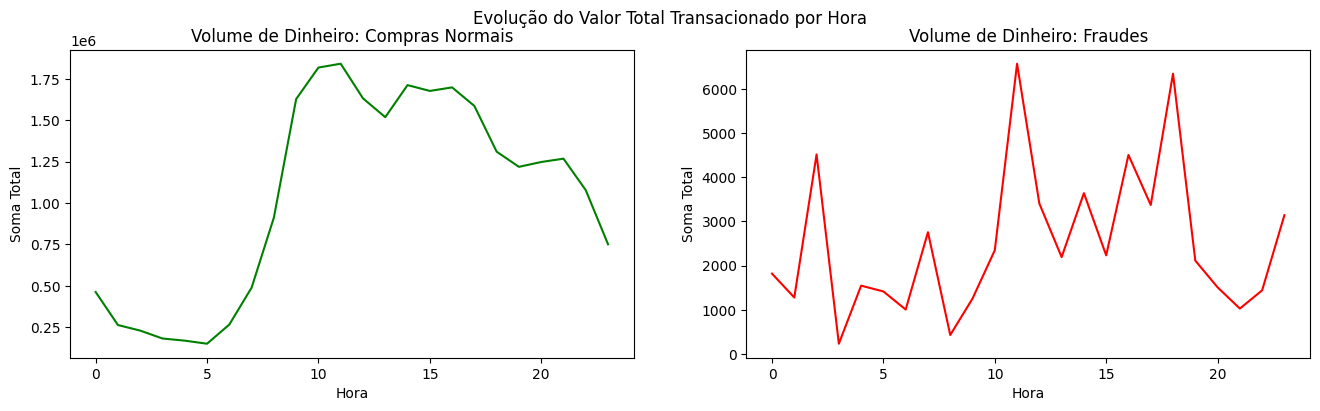

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,4))
sns.lineplot(ax=ax1, x="Hora", y="Soma Total", data=dataf.loc[dataf.Classe==0], color="green")
ax1.set_title("Volume de Dinheiro: Compras Normais")
sns.lineplot(ax=ax2, x="Hora", y="Soma Total", data=dataf.loc[dataf.Classe==1], color="red")
ax2.set_title("Volume de Dinheiro: Fraudes")
plt.suptitle("Evolução do Valor Total Transacionado por Hora")
plt.show()

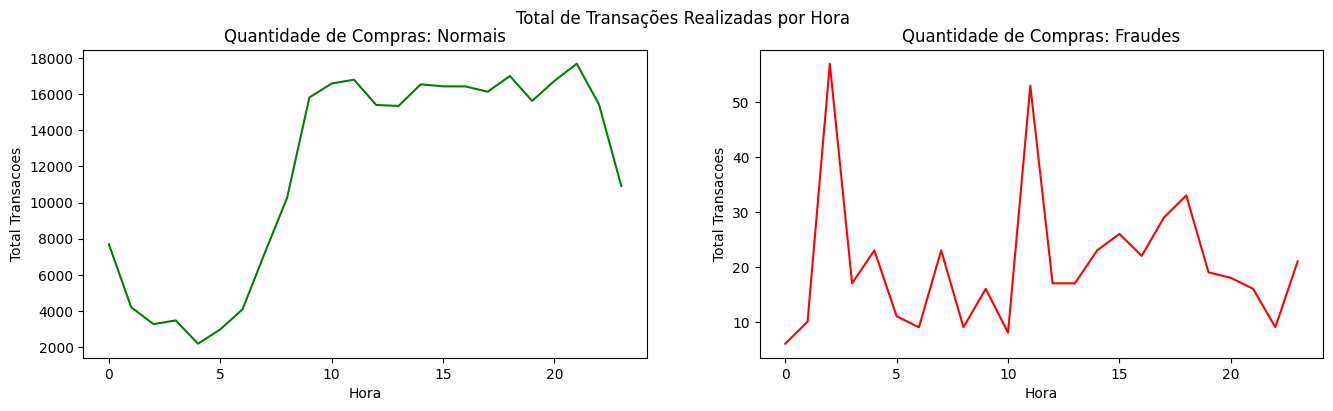

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16,4))
sns.lineplot(ax=ax1, x="Hora", y="Total Transacoes", data=dataf.loc[dataf.Classe==0], color="green")
ax1.set_title("Quantidade de Compras: Normais")
sns.lineplot(ax=ax2, x="Hora", y="Total Transacoes", data=dataf.loc[dataf.Classe==1], color="red")
ax2.set_title("Quantidade de Compras: Fraudes")
plt.suptitle("Total de Transações Realizadas por Hora")
plt.show()

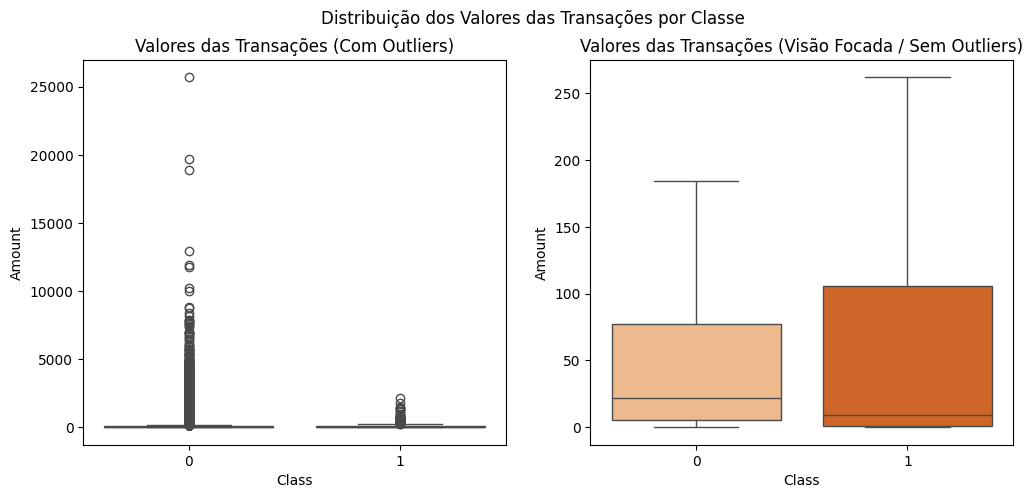

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
sns.boxplot(ax=ax1, x="Class", y="Amount", hue="Class", data=df, palette="Oranges", legend=False, showfliers=True)
ax1.set_title("Valores das Transações (Com Outliers)") 
sns.boxplot(ax=ax2, x="Class", y="Amount", hue="Class", data=df, palette="Oranges", legend=False, showfliers=False)
ax2.set_title("Valores das Transações (Visão Focada / Sem Outliers)")
plt.suptitle("Distribuição dos Valores das Transações por Classe")
plt.show()

In [12]:
X = df.drop(columns=['Class', 'Hora'])
y = df['Class']

print("1. Pistas e Respostas separadas com sucesso!")
print(f"Formato das Pistas (X): {X.shape} | Formato das Respostas (y): {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
    )

print("\n2. Divisão de Treino e Teste concluída!")
print(f"-> Dados de Treino para a IA estudar (X_train): {X_train.shape[0]} linhas")
print(f"-> Dados de Teste para fazer a prova (X_test): {X_test.shape[0]} linhas")

1. Pistas e Respostas separadas com sucesso!
Formato das Pistas (X): (284807, 30) | Formato das Respostas (y): (284807,)

2. Divisão de Treino e Teste concluída!
-> Dados de Treino para a IA estudar (X_train): 227845 linhas
-> Dados de Teste para fazer a prova (X_test): 56962 linhas


In [15]:
from sklearn.ensemble import RandomForestClassifier
ia = RandomForestClassifier(n_estimators=50, random_state=12, n_jobs=-1)


print("Iniciando o treinamento da Inteligência Artificial...")
print("O robô está lendo o histórico e criando as regras de segurança... Aguarde.")

ia.fit(X_train, y_train)

print("\n[SUCESSO] Treinamento concluído!")
print("A IA agora já aprendeu a diferenciar um cliente comum de um fraudador.")

Iniciando o treinamento da Inteligência Artificial...
O robô está lendo o histórico e criando as regras de segurança... Aguarde.

[SUCESSO] Treinamento concluído!
A IA agora já aprendeu a diferenciar um cliente comum de um fraudador.


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
relatorio_en = classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude'])

# Traduzindo os termos padrões do inglês para o português
relatorio_pt = relatorio_en.replace('precision', 'Precisão')\
                           .replace('recall', 'Recall')\
                           .replace('f1-score', 'F1-Score')\
                           .replace('support', 'Suporte')\
                           .replace('accuracy', 'Acurácia')\
                           .replace('macro avg', 'Média Macro')\
                           .replace('weighted avg', 'Média Ponderada')

A IA está analisando as transações inéditas de teste...


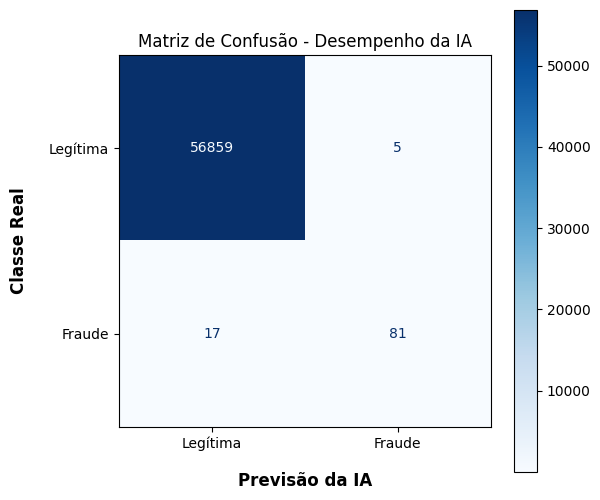


================ RELATÓRIO DE MÉTRICAS ================
              Precisão    Recall  F1-Score   Suporte

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.94      0.83      0.88        98

    Acurácia                           1.00     56962
   Média Macro       0.97      0.91      0.94     56962
Média Ponderada       1.00      1.00      1.00     56962



In [22]:
print("A IA está analisando as transações inéditas de teste...")
y_pred = ia.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítima', 'Fraude'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

ax.set_xlabel('Previsão da IA', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Classe Real', fontsize=12, fontweight='bold', labelpad=15)

plt.title('Matriz de Confusão - Desempenho da IA')
plt.grid(False) 
plt.show()

print("\n================ RELATÓRIO DE MÉTRICAS ================")
print(relatorio_pt)
print("=======================================================")